<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/machina_learning/lab%20-%20XGBoost%20and%20Gradient%20Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XGBoost: Gradient Boosting from Theory to Practice

## Introduction

**XGBoost** (eXtreme Gradient Boosting, Chen & Guestrin, 2016) is an ensemble method that has dominated machine learning competitions. It builds on **gradient boosting**, which combines many weak learners (shallow decision trees) sequentially, with each tree correcting the errors of its predecessors.

### Ensemble Methods: Taxonomy

| Method | Strategy | Reduces | Example |
|--------|----------|---------|---------|
| **Bagging** | Train $B$ independent learners on bootstrap samples, average | Variance | Random Forest |
| **Boosting** | Train learners sequentially, each correcting previous errors | Bias | AdaBoost, GBM, XGBoost |
| **Stacking** | Train a meta-learner on base learner predictions | Both | General ensembles |

### Gradient Boosting Framework

Given loss $\mathcal{L}(y, F(\mathbf{x}))$, we build an additive model:
$$F_T(\mathbf{x}) = F_0(\mathbf{x}) + \sum_{t=1}^T \eta \cdot f_t(\mathbf{x})$$

where $\eta$ is the **learning rate (shrinkage)** and each $f_t$ is fitted to the **pseudo-residuals** (negative gradient of the loss):
$$r_i^{(t)} = -\left[\frac{\partial \mathcal{L}(y^{(i)}, F(\mathbf{x}^{(i)}))}{\partial F(\mathbf{x}^{(i)})}\right]_{F = F_{t-1}}$$

For MSE loss $\mathcal{L} = \frac{1}{2}(y-F)^2$: $r_i = y^{(i)} - F_{t-1}(\mathbf{x}^{(i)})$ — simply the residuals.  
For log-loss: $r_i = y^{(i)} - \sigma(F_{t-1}(\mathbf{x}^{(i)}))$ — similar to logistic regression's gradient.

### XGBoost's Key Innovations

**1. Second-order Taylor expansion** of the loss:
$$\mathcal{L}^{(t)} \approx \sum_{i=1}^m \left[g_i f_t(\mathbf{x}^{(i)}) + \frac{1}{2}h_i f_t(\mathbf{x}^{(i)})^2\right] + \Omega(f_t)$$

where $g_i = \partial_F \mathcal{L}(y^{(i)}, F_{t-1})$ and $h_i = \partial^2_F \mathcal{L}(y^{(i)}, F_{t-1})$ are the first and second derivatives.

**2. Tree regularisation** term:
$$\Omega(f_t) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^T w_j^2$$

where $T$ = number of leaves, $w_j$ = weight of leaf $j$. This penalises overly complex trees.

**3. Optimal leaf weights and split gain:**

For each leaf $j$ with sample set $I_j$: $G_j = \sum_{i \in I_j} g_i$, $H_j = \sum_{i \in I_j} h_i$

$$w_j^* = -\frac{G_j}{H_j + \lambda}$$

Gain from splitting leaf $j$ into left $L$ and right $R$:
$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

A split is made only if $\text{Gain} > 0$.

### Key Hyperparameters

| Parameter | Default | Meaning | Effect of increasing |
|-----------|---------|---------|---------------------|
| `n_estimators` | 100 | Number of trees | Lower bias, more overfit |
| `max_depth` | 6 | Max tree depth | Higher capacity, overfit |
| `learning_rate` $\eta$ | 0.3 | Shrinkage per tree | Need more trees, better generalisation |
| `subsample` | 1.0 | Row subsampling ratio | Reduces variance (like bagging) |
| `colsample_bytree` | 1.0 | Feature subsampling | Reduces variance |
| `reg_lambda` $\lambda$ | 1 | L2 on leaf weights | Smoother trees |
| `reg_alpha` $\alpha$ | 0 | L1 on leaf weights | Sparse leaf weights |
| `gamma` $\gamma$ | 0 | Min gain for split | Prunes shallow splits |

## Imports & Usefull material

We will the use of XGBoost and its integration with Scikit-Learn.

Some useful links:


*   [XGBoost documentation](https://xgboost.readthedocs.io/en/latest/index.html)
*   [Parameters](https://xgboost.readthedocs.io/en/latest/parameter.html)
*   [Python package](https://xgboost.readthedocs.io/en/latest/python/python_intro.html)




Objective is to demonstrate:


*   regression ✓
*   binary classification ✓
*   multiclass classification ✓
*   cross-validation ✓
*   hyperparameter searching ✓
*   feature importance ✓
*   early stopping ✓
*   evaluations
*   plotting ✓



**Note:** XGBoost supports GPU acceleration (`tree_method='gpu_hist'` or `device='cuda'`), which is especially beneficial for large datasets. For this notebook a CPU is sufficient.

Let us start with some imports:

In [11]:
!pip3 install --upgrade xgboost

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint

from sklearn.datasets import load_breast_cancer, load_diabetes, load_wine
from sklearn.metrics import auc, accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import (cross_val_score, GridSearchCV, KFold,
                                     RandomizedSearchCV, train_test_split)
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

plt.style.use('seaborn-v0_8-whitegrid')

And define a couple of functions:

In [13]:
def display_scores(scores):
    """Print CV score summary: individual folds, mean, and std."""
    print("-" * 45)
    print(f"  RMSE scores : {np.round(scores, 3)}")
    print(f"  Mean  RMSE  : {np.mean(scores):.4f}")
    print(f"  Std   RMSE  : {np.std(scores):.4f}")
    print("-" * 45)

In [14]:
def report_best_scores(results, n_top=3):
    """Print top-n models from a GridSearch/RandomizedSearch result."""
    for rank in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == rank)
        for candidate in candidates:
            print("-" * 55)
            print(f"  Rank #{rank}")
            print(f"  Mean CV score : {results['mean_test_score'][candidate]:.4f}"
                  f"  (±{results['std_test_score'][candidate]:.4f})")
            print(f"  Parameters    : {results['params'][candidate]}")
    print("-" * 55)

## 1. Regression: Diabetes Dataset

**Dataset:** The [sklearn Diabetes dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html) has $m=442$ patients and $n=10$ features (age, sex, BMI, blood pressure, 6 blood serum measurements). The target is a quantitative measure of disease progression.

We evaluate using:
- **MSE**: $\frac{1}{m}\sum_i(y^{(i)}-\hat{y}^{(i)})^2$ — penalises large errors quadratically
- **RMSE**: $\sqrt{\text{MSE}}$ — same units as the target
- **$R^2$**: $1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$ — proportion of variance explained

In [15]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

print("-" * 50)
print("  Diabetes Regression Dataset")
print("-" * 50)
print(f"  Samples     : {X.shape[0]}")
print(f"  Features    : {X.shape[1]}")
print(f"  Target range: [{y.min():.0f}, {y.max():.0f}]  (mean={y.mean():.1f})")
print(f"  Feature names: {diabetes.feature_names}")
print("-" * 50)

--------------------------------------------------
  Diabetes Regression Dataset
--------------------------------------------------
  Samples     : 442
  Features    : 10
  Target range: [25, 346]  (mean=152.1)
  Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
--------------------------------------------------


In [16]:
print(f"  Feature means : {np.mean(X, axis=0).round(4)}")
print(f"  Feature maxes : {np.max(X,  axis=0).round(4)}")
print(f"  Feature mins  : {np.min(X,  axis=0).round(4)}")

  Feature means : [-0.  0. -0. -0. -0.  0. -0. -0.  0.  0.]
  Feature maxes : [0.1107 0.0507 0.1706 0.132  0.1539 0.1988 0.1812 0.1852 0.1336 0.1356]
  Feature mins  : [-0.1072 -0.0446 -0.0903 -0.1124 -0.1268 -0.1156 -0.1023 -0.0764 -0.1261
 -0.1378]


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Proper train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (353, 10), Test: (89, 10)


In [18]:
import xgboost as xgb

xgb_reg = xgb.XGBRegressor(objective="reg:squarederror", random_state=42,
                             n_estimators=200, learning_rate=0.1, max_depth=4)
xgb_reg.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_train = xgb_reg.predict(X_train)
y_pred_test  = xgb_reg.predict(X_test)

print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.3f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f}")
print(f"Train R²:   {r2_score(y_train, y_pred_train):.4f}")
print(f"Test  R²:   {r2_score(y_test, y_pred_test):.4f}")

Train RMSE: 11.505
Test  RMSE: 59.160
Train R²:   0.9782
Test  R²:   0.3394


And the final model is:

In [19]:
print(xgb_reg)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


xgb_model

## 2. Binary Classification: Breast Cancer Dataset

**Dataset:** The [Breast Cancer Wisconsin dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) has $m=569$ samples and $n=30$ features (measurements of cell nuclei). Target: malignant (0) or benign (1).

For binary classification, XGBoost uses `objective="binary:logistic"` which outputs probabilities $\hat{p} = \sigma(F(\mathbf{x}))$ and minimises log-loss.

We also apply **StandardScaler** — while tree-based methods are scale-invariant, scaling ensures fair comparison and benefits potential future use of the features with other models.

In [20]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

In [21]:
print(X.shape)
print(y.shape)
print(X[:3,:])

(569, 30)
(569,)
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]]


In [22]:
print(f"  Feature means : {np.mean(X, axis=0).round(4)}")
print(f"  Feature maxes : {np.max(X,  axis=0).round(4)}")
print(f"  Feature mins  : {np.min(X,  axis=0).round(4)}")

  Feature means : [1.412730e+01 1.928960e+01 9.196900e+01 6.548891e+02 9.640000e-02
 1.043000e-01 8.880000e-02 4.890000e-02 1.812000e-01 6.280000e-02
 4.052000e-01 1.216900e+00 2.866100e+00 4.033710e+01 7.000000e-03
 2.550000e-02 3.190000e-02 1.180000e-02 2.050000e-02 3.800000e-03
 1.626920e+01 2.567720e+01 1.072612e+02 8.805831e+02 1.324000e-01
 2.543000e-01 2.722000e-01 1.146000e-01 2.901000e-01 8.390000e-02]
  Feature maxes : [2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 3.454e-01 4.268e-01
 2.012e-01 3.040e-01 9.740e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.110e-02 1.354e-01 3.960e-01 5.280e-02 7.900e-02 2.980e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.910e-01
 6.638e-01 2.075e-01]
  Feature mins  : [6.981e+00 9.710e+00 4.379e+01 1.435e+02 5.260e-02 1.940e-02 0.000e+00
 0.000e+00 1.060e-01 5.000e-02 1.115e-01 3.602e-01 7.570e-01 6.802e+00
 1.700e-03 2.300e-03 0.000e+00 0.000e+00 7.900e-03 9.000e-04 7.930e+00
 1.202e+01 5.041e+01 1.852e+02

In [23]:
scaler = StandardScaler()
X = scaler.fit_transform(X) # Or first scaler=fit(X) -> then X = scaler.transform(X)

In [24]:
print(f"  Feature means : {np.mean(X, axis=0).round(4)}")
print(f"  Feature maxes : {np.max(X,  axis=0).round(4)}")
print(f"  Feature mins  : {np.min(X,  axis=0).round(4)}")

  Feature means : [-0. -0. -0. -0.  0. -0. -0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0. -0.
 -0. -0. -0.  0. -0.  0. -0. -0.  0. -0. -0.  0.]
  Feature maxes : [ 3.9713  4.6519  3.9761  5.2505  4.7709  4.5684  4.2436  3.9279  4.4848
  4.9109  8.9069  6.6553  9.462  11.0418  8.03    6.1435 12.0727  6.6496
  7.0719  9.8516  4.0942  3.8859  4.2873  5.9302  3.9554  5.1129  4.7007
  2.6859  6.046   6.8469]
  Feature mins  : [-2.0296 -2.2292 -1.9845 -1.4544 -3.1121 -1.6101 -1.1149 -1.2618 -2.7441
 -1.8199 -1.0599 -1.5543 -1.044  -0.7378 -1.7761 -1.2981 -1.0575 -1.9134
 -1.5329 -1.097  -1.7269 -2.224  -1.6934 -1.2224 -2.6827 -1.4439 -1.3058
 -1.7451 -2.161  -1.6018]


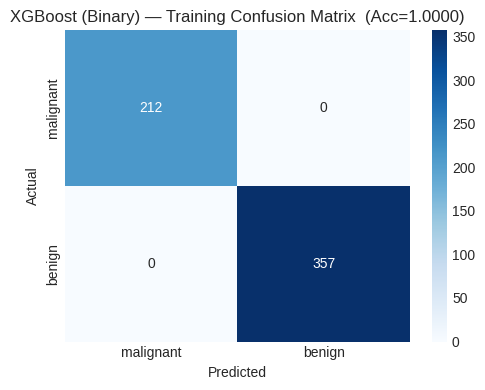

In [25]:
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X, y)
y_pred = xgb_model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'XGBoost (Binary) — Training Confusion Matrix  (Acc={acc:.4f})')
plt.tight_layout()
plt.show()

## 3. Multiclass Classification: Wine Dataset

**Dataset:** The [Wine dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) has $m=178$ samples, $n=13$ features (chemical properties), and $K=3$ classes.

XGBoost handles multiclass via `objective="multi:softprob"`, which applies the **softmax** function:
$$\hat{P}(y=k \mid \mathbf{x}) = \frac{e^{F_k(\mathbf{x})}}{\sum_{j=1}^K e^{F_j(\mathbf{x})}}$$

XGBoost trains $K$ trees per boosting round (one per class) and minimises categorical cross-entropy.

In [26]:
wine = load_wine()

X = wine.data
y = wine.target

In [27]:
print(np.unique(y))

[0 1 2]


In [28]:
print(X.shape)

(178, 13)


The Wine dataset has 178 samples of 13 features (chemical properties of wines from three cultivars). Unlike the breast cancer dataset, we have 3 classes here — this requires the multiclass objective.

In [29]:
scaler2 = StandardScaler()
X = scaler2.fit_transform(X) # Or first scaler=fit(X) -> then X = scaler.transform(X)

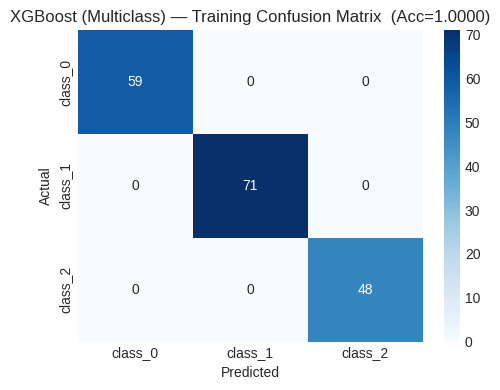

In [30]:
xgb_model = xgb.XGBClassifier(objective="multi:softprob", random_state=42)
xgb_model.fit(X, y)
y_pred = xgb_model.predict(X)

cm  = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=wine.target_names, yticklabels=wine.target_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'XGBoost (Multiclass) — Training Confusion Matrix  (Acc={acc:.4f})')
plt.tight_layout()
plt.show()

## 4. Cross-Validation

$k$-fold cross-validation gives a reliable, low-variance estimate of generalisation performance by training and evaluating on $k$ different train/validation splits.

**Why this matters for boosting:** Boosted models are prone to overfitting if `n_estimators` is too large or `learning_rate` is too high. CV helps select the optimal configuration before training the final model on all data.

In [31]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

scores = []

for train_index, test_index in kfold.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    xgb_model = xgb.XGBRegressor(objective="reg:squarederror")
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)

    scores.append(mean_squared_error(y_test, y_pred))

display_scores(np.sqrt(scores))

---------------------------------------------
  RMSE scores : [59.582 63.799 53.615 71.499 74.58  66.232 63.625 70.379 64.304 63.943]
  Mean  RMSE  : 65.1557
  Std   RMSE  : 5.7284
---------------------------------------------


## 5. Hyperparameter Search

**Random search** is often more efficient than grid search for XGBoost, since many hyperparameters have diminishing returns beyond a threshold. We search over a probability distribution for each parameter.

**Key insight:** `learning_rate` and `n_estimators` are tightly coupled. A common strategy:
1. Set a small `learning_rate` (e.g., 0.01–0.05) and large `n_estimators`
2. Use **early stopping** to find the optimal number of trees
3. Then grid-search other hyperparameters

In [32]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

xgb_model = xgb.XGBRegressor(objective="reg:squarederror")

params = {
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma": uniform(0, 0.5),
    "learning_rate": uniform(0.03, 0.3), # default 0.1
    "max_depth": randint(2, 6), # default 3
    "n_estimators": randint(100, 150), # default 100
    "subsample": uniform(0.6, 0.4)
}

search = RandomizedSearchCV(xgb_model, param_distributions=params, random_state=42, n_iter=200, cv=3, verbose=1, n_jobs=1, return_train_score=True)

search.fit(X, y)

report_best_scores(search.cv_results_, 1)

Fitting 3 folds for each of 200 candidates, totalling 600 fits
-------------------------------------------------------
  Rank #1
  Mean CV score : 0.4666  (±0.0190)
  Parameters    : {'colsample_bytree': np.float64(0.7902634929450308), 'gamma': np.float64(0.1424202471887338), 'learning_rate': np.float64(0.041066084206359835), 'max_depth': 2, 'n_estimators': 101, 'subsample': np.float64(0.8010716092915446)}
-------------------------------------------------------


## 6. Early Stopping and Learning Curves

**Early stopping** monitors a validation metric during training and stops when it stops improving for `early_stopping_rounds` consecutive rounds. This prevents overfitting and is computationally efficient.

**Key formula:** with early stopping, we find $T^* = \arg\min_T \text{ValidationLoss}(T)$. Then we retrain on all data using $T = T^*$ trees to get the final model.

> **Important:** `xgb_model.fit()` with early stopping returns the model from the **last** iteration, not the best. Use `xgb_model.best_iteration + 1` as `n_estimators` when retraining.

In [33]:
import xgboost, sklearn
print(f"xgboost     : {xgboost.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

xgboost     : 3.4.1
scikit-learn: 1.6.1


In [34]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

# if more than one evaluation metric are given the last one is used for early stopping
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    eval_metric="auc",
    n_estimators=1000,
    early_stopping_rounds=5
)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

from xgboost.callback import EarlyStopping

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
)

y_pred = xgb_model.predict(X_test)

accuracy_score(y_test, y_pred)

[0]	validation_0-auc:0.95797
[1]	validation_0-auc:0.96900
[2]	validation_0-auc:0.97566
[3]	validation_0-auc:0.97389
[4]	validation_0-auc:0.97826
[5]	validation_0-auc:0.98991
[6]	validation_0-auc:0.99147
[7]	validation_0-auc:0.99168
[8]	validation_0-auc:0.99105
[9]	validation_0-auc:0.99272
[10]	validation_0-auc:0.99355
[11]	validation_0-auc:0.99334
[12]	validation_0-auc:0.99376
[13]	validation_0-auc:0.99293
[14]	validation_0-auc:0.99251
[15]	validation_0-auc:0.99272
[16]	validation_0-auc:0.99293
[17]	validation_0-auc:0.99293


0.958041958041958

In [35]:
print("-" * 50)
print(f"  Best iteration : {xgb_model.best_iteration}")
print(f"  Best AUC score : {xgb_model.best_score:.4f}")
print(f"  → Retrain with n_estimators = {xgb_model.best_iteration + 1}")
print("-" * 50)

--------------------------------------------------
  Best iteration : 12
  Best AUC score : 0.9938
  → Retrain with n_estimators = 13
--------------------------------------------------


xgb_model.fit() will produce a model from the last iteration, not the best one, so to get the optimum model consider retraining over xgb_model.best_iteration.

In [36]:
n_estimators = xgb_model.best_iteration + 1 # best started from 0
xgb_model = xgb.XGBClassifier(objective="binary:logistic", n_estimators=n_estimators, random_state=42, eval_metric=["auc"])
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

[0]	validation_0-auc:0.95797
[1]	validation_0-auc:0.96900
[2]	validation_0-auc:0.97566
[3]	validation_0-auc:0.97389
[4]	validation_0-auc:0.97826
[5]	validation_0-auc:0.98991
[6]	validation_0-auc:0.99147
[7]	validation_0-auc:0.99168
[8]	validation_0-auc:0.99105
[9]	validation_0-auc:0.99272
[10]	validation_0-auc:0.99355
[11]	validation_0-auc:0.99334
[12]	validation_0-auc:0.99376


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=['auc'], feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=13,
              n_jobs=None, num_parallel_tree=None, ...)

## 7. Evaluation with Confusion Matrix and ROC Curve

Beyond accuracy, we want to understand *where* the model makes mistakes. The **confusion matrix** and **ROC curve** give a complete picture.

In [37]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

xgb_model = xgb.XGBClassifier(objective="binary:logistic", n_estimators=20, random_state=42, eval_metric=["auc", "error"])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

y_pred = xgb_model.predict(X_test)

[0]	validation_0-auc:0.95797	validation_0-error:0.08392
[1]	validation_0-auc:0.96900	validation_0-error:0.05594
[2]	validation_0-auc:0.97566	validation_0-error:0.03497
[3]	validation_0-auc:0.97389	validation_0-error:0.04196
[4]	validation_0-auc:0.97826	validation_0-error:0.02797
[5]	validation_0-auc:0.98991	validation_0-error:0.03497
[6]	validation_0-auc:0.99147	validation_0-error:0.03497
[7]	validation_0-auc:0.99168	validation_0-error:0.03497
[8]	validation_0-auc:0.99105	validation_0-error:0.04196
[9]	validation_0-auc:0.99272	validation_0-error:0.04196
[10]	validation_0-auc:0.99355	validation_0-error:0.04196
[11]	validation_0-auc:0.99334	validation_0-error:0.04196
[12]	validation_0-auc:0.99376	validation_0-error:0.04196
[13]	validation_0-auc:0.99293	validation_0-error:0.04196
[14]	validation_0-auc:0.99251	validation_0-error:0.04196
[15]	validation_0-auc:0.99272	validation_0-error:0.04196
[16]	validation_0-auc:0.99293	validation_0-error:0.04196
[17]	validation_0-auc:0.99293	validation_

## 8. Feature Importance

XGBoost computes three types of feature importance:

| Type | Description | When to prefer |
|------|-------------|----------------|
| **`weight`** | Number of times feature is used in splits | Quick, but biased towards high-cardinality features |
| **`gain`** | Average improvement in loss from splits using this feature | Most informative for feature selection |
| **`cover`** | Average number of samples covered by splits using this feature | Useful for understanding data coverage |

> **Note:** Tree-based feature importance can be misleading when features are correlated. For more robust importance estimation, consider **permutation importance** or **SHAP values** (SHapley Additive exPlanations).

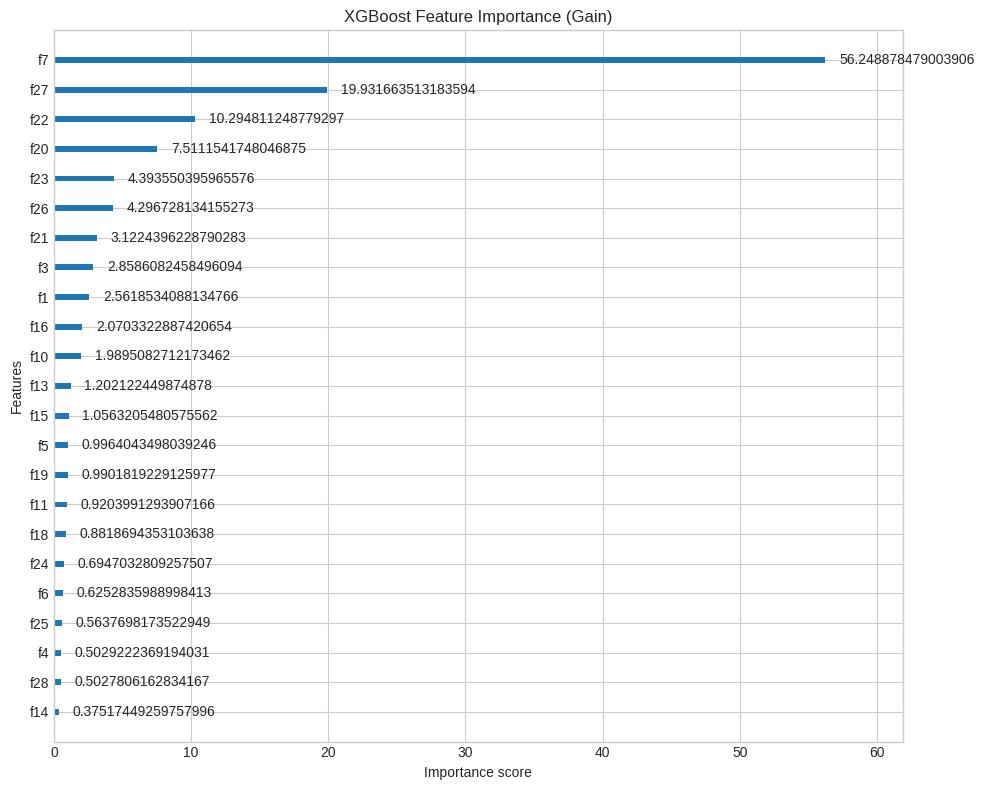

/usr/local/lib/python3.13/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` instead. 
  warnings.warn(


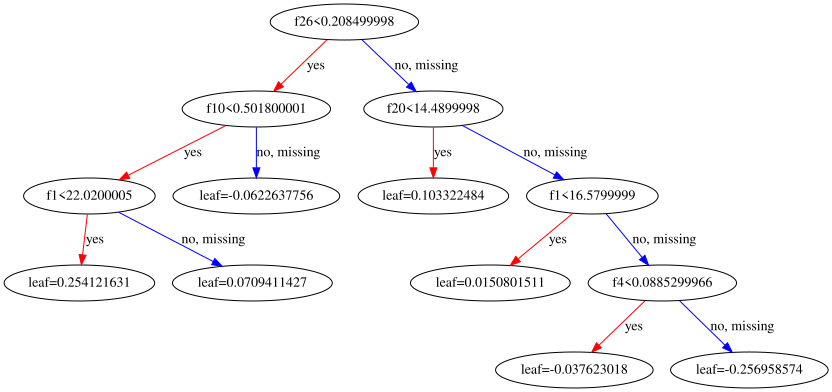

In [38]:
# requires graphviz and python-graphviz conda packages
import graphviz

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42, eval_metric="auc", early_stopping_rounds=10)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(xgb_model, ax=ax, importance_type='gain',
                    title='XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.show()

# plot the output tree via matplotlib, specifying the ordinal number of the target tree
# xgb.plot_tree(xgb_model, num_trees=xgb_model.best_iteration)

# converts the target tree to a graphviz instance
xgb.to_graphviz(xgb_model, num_trees=xgb_model.best_iteration)

### Learning Curves: Training vs. Validation Loss

Learning curves help diagnose whether we are overfitting or underfitting. We plot the training and validation loss across boosting rounds:

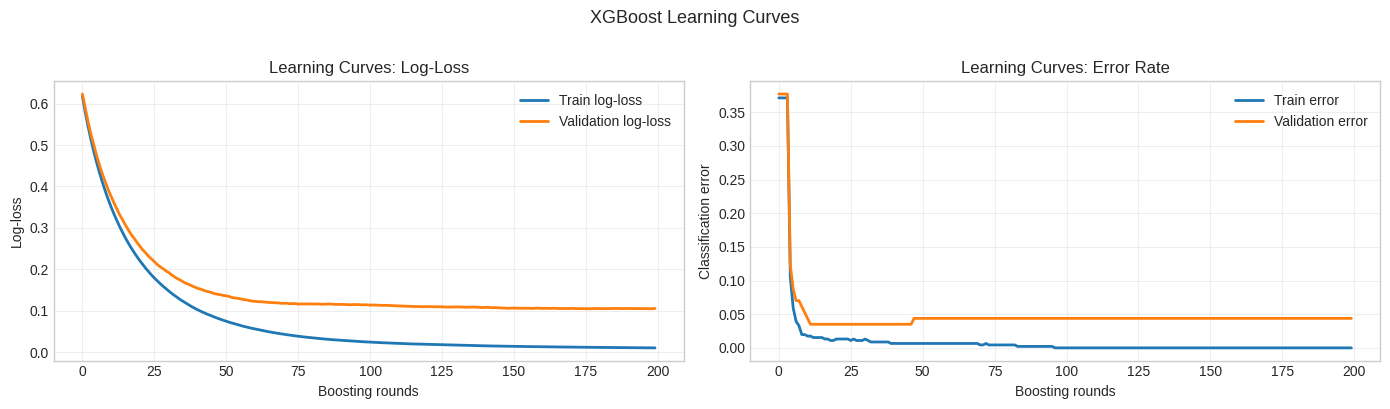

Final generalisation gap (val-train log-loss): 0.0952
If gap is large → overfitting. Try: lower learning_rate, smaller max_depth, larger lambda.


In [39]:
# Plot learning curves
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np

cancer = load_breast_cancer()
X_lc, y_lc = cancer.data, cancer.target
X_lc = StandardScaler().fit_transform(X_lc)
X_tr, X_val, y_tr, y_val = train_test_split(X_lc, y_lc, test_size=0.2, random_state=42)

model_lc = xgb.XGBClassifier(
    objective="binary:logistic", n_estimators=200,
    learning_rate=0.05, max_depth=4, random_state=42,
    eval_metric=['logloss', 'error']
)
model_lc.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False)

results = model_lc.evals_result()
epochs = len(results['validation_0']['logloss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(results['validation_0']['logloss'], label='Train log-loss', lw=2)
ax1.plot(results['validation_1']['logloss'], label='Validation log-loss', lw=2)
ax1.set_xlabel('Boosting rounds'); ax1.set_ylabel('Log-loss')
ax1.set_title('Learning Curves: Log-Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(results['validation_0']['error'], label='Train error', lw=2)
ax2.plot(results['validation_1']['error'], label='Validation error', lw=2)
ax2.set_xlabel('Boosting rounds'); ax2.set_ylabel('Classification error')
ax2.set_title('Learning Curves: Error Rate'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('XGBoost Learning Curves', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

gap = np.array(results['validation_1']['logloss']) - np.array(results['validation_0']['logloss'])
print(f"Final generalisation gap (val-train log-loss): {gap[-1]:.4f}")
print("If gap is large → overfitting. Try: lower learning_rate, smaller max_depth, larger lambda.")

## Reflection Questions

1. **Boosting vs. Bagging.** Gradient boosting reduces bias by fitting each tree to the residuals of the previous ensemble. Random Forest reduces variance by averaging independent trees. Which is more sensitive to noisy labels? Which benefits more from adding more trees?

2. **Second-order information.** Standard gradient boosting uses only first-order gradients ($g_i$). XGBoost also uses second-order gradients ($h_i$). When does the second-order information provide the most benefit? (Hint: think about highly curved loss functions.)

3. **Learning rate and shrinkage.** Why does a smaller learning rate $\eta$ often yield better generalisation? Prove that with $\eta \to 0$ and $T \to \infty$ (such that $\eta T = \text{const}$), the model approaches a continuous gradient flow. What is the practical implication?

4. **Early stopping.** If you train with early stopping and find $T^* = 47$, should you retrain on the full training data with `n_estimators=47`? Or on a slightly larger number? Explain the reasoning.

5. **SHAP values.** Traditional feature importance (`gain`, `weight`) is a global metric. SHAP values provide **per-sample** attribution: $f(\mathbf{x}) = \phi_0 + \sum_j \phi_j(\mathbf{x})$ where $\phi_j$ is the contribution of feature $j$ to this prediction. How does this help diagnose model behaviour compared to global importance?

## Answers to Reflection Questions

**1. Boosting vs. Bagging.**
Gradient boosting **reduces bias**: each tree is fit to the residuals of the current ensemble, directly correcting systematic errors. Random Forest **reduces variance**: individual trees are high-variance but uncorrelated; averaging cancels out their random errors. Boosting is more sensitive to noisy labels because it keeps fitting to residuals — mislabelled points are "hard" and get increasingly large residuals, causing the ensemble to memorise them. Bagging is more robust because outliers appear in only ~63% of bootstrap samples and their influence is diluted by averaging. Adding more trees eventually plateaus for RF; for boosting, too many trees → overfitting.

---

**2. Second-order information.**
The second-order term $h_i = \partial^2_F \mathcal{L}$ acts as a per-sample **adaptive learning rate**: if $h_i$ is large (the loss is highly curved at sample $i$), the optimal leaf weight $w^* = -G_j/(H_j+\lambda)$ is smaller in magnitude — preventing overshooting. For MSE, $h_i = 1$ (constant curvature), so first and second order are equivalent. For log-loss, $h_i = a^{(i)}(1-a^{(i)})$ — near the boundary ($a \approx 0.5$), curvature is high and steps are smaller; near certainty, curvature is low and steps are larger. Second-order information matters most for non-quadratic, highly non-uniform loss surfaces.

---

**3. Learning rate and shrinkage.**
Shrinkage multiplies each tree by $\eta$ before adding it to the ensemble: $F_t = F_{t-1} + \eta f_t$. A smaller $\eta$ means each tree makes a smaller contribution, requiring more trees ($T$) for the same total "movement." The benefit: more correction opportunities, smoother convergence, less risk that a single bad tree dominates. In the limit $\eta \to 0, T \to \infty, \eta T = \text{const}$: the discrete sum becomes the continuous gradient flow $\dot{F} = -\nabla_F \mathcal{L}$. Practically: use small $\eta$ (0.01–0.1) with early stopping to find the optimal $T$.

---

**4. Early stopping and retraining.**
With early stopping on a validation split, you find $T^*$ = best iteration. The model trained with early stopping used only part of the training data (since some was held out as validation). To make full use of the data, **retrain on all data** using `n_estimators = T^*`. You should not use a larger number (e.g., $T^* + \text{buffer}$) since the optimal number of trees may shift slightly when using more training data — but $T^*$ from early stopping is a reasonable estimate.

---

**5. SHAP values.**
Global importance (gain, weight) aggregates over all samples and predictions — it tells you which features the model *usually* uses but not *why it predicted X for this specific patient*. SHAP gives each feature a **per-prediction contribution** $\phi_j(\mathbf{x})$ satisfying:
- Efficiency: $\sum_j \phi_j(\mathbf{x}) = f(\mathbf{x}) - \mathbb{E}[f]$ (contributions sum to the prediction)  
- Consistency and local accuracy (Lundberg & Lee, 2017)

This enables debugging ("why did the model give this person a high credit risk?"), detecting bias, and building trust — things global importance cannot provide.